In [9]:
import pandas as pd
import xarray as xr
from sea_breeze.load_model_data import (
    load_aus2200_variable, 
    interp_model_level_to_z, 
    load_aus2200_static, 
    aus2200_hybrid_height_calc, 
    load_barra_static)
from sea_breeze.sea_breeze_funcs import rotate_wind
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from dask.distributed import Client
from metpy.interpolate import cross_section
import metpy.calc as mpcalc
import metpy.units as units
import numpy as np

In [10]:
def create_transects(start_coast,end_coast,delta_transect=0.022,D=0.5):

    """
    start_coast: [lat, lon] pairing of start transect central point
    end_coast: [lat, lon] pairing of end transect central point
    delta_transct (float): spacing between transect central points from start_coast to end_coast (degrees)
    D (float): length of transects (degrees)
    """

    angle = np.rad2deg(np.arctan2( (end_coast[0]-start_coast[0]) , (end_coast[1]-start_coast[1]) ))

    point_dist = np.sqrt((end_coast[0]-start_coast[0])**2 + (end_coast[1]-start_coast[1])**2)
    
    center_points = []
    for delta in np.arange(0,point_dist,delta_transect):
        center_points.append(
            [start_coast[0] + delta * np.sin(np.deg2rad(angle)), 
             start_coast[1] + delta * np.cos(np.deg2rad(angle))])
    
    angle_rotated = angle-90
    if angle_rotated < 0:
        angle_rotated = angle_rotated+360
    
    end_points = []
    start_points = []
    for c in center_points:
        end_points.append(
            [c[0] + D * np.sin(np.deg2rad(angle_rotated)), 
             c[1] + D * np.cos(np.deg2rad(angle_rotated))])
        start_points.append(
            [c[0] - D * np.sin(np.deg2rad(angle_rotated)), 
             c[1] - D * np.cos(np.deg2rad(angle_rotated))])    

    print(len(end_points), " transects")
    
    return center_points, start_points, end_points

def transect_to_csv(start_points,end_points,out_name):

    path = "/g/data/ng72/ab4502/coastline_data/transect_points/"
    
    pd.DataFrame(
        {"start_lat":[start_points[i][0] for i in np.arange(len(start_points))],
         "start_lon":[start_points[i][1] for i in np.arange(len(start_points))],
         "end_lat":[end_points[i][0] for i in np.arange(len(end_points))],
         "end_lon":[end_points[i][1] for i in np.arange(len(end_points))],
        }).to_csv(path+out_name+".csv")    

## Illawarra

In [11]:
region="illawara"
lat_slice = slice(-36,-32.5)
lon_slice = slice(148.5,153.5)
orog, lsm = load_aus2200_static("mjo-elnino2016",lon_slice,lat_slice)
angle_ds = xr.open_dataset(
        "/g/data/ng72/ab4502/coastline_data/aus2200.nc"
    ).sel(lat=lat_slice,lon=lon_slice)
shapes = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes.nc").sel(lat=lat_slice,lon=lon_slice)

10  transects
10  transects
11  transects


Text(151.0057, -33.8727, 'Sydney')

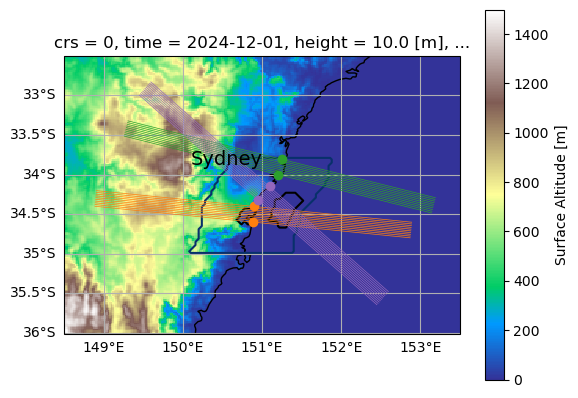

In [12]:
#transect setting (length in degrees is 2*D)
D=2
delta=0.022

#The spacing in degrees of the transect central points
start_coast_1 = [-34.6,150.88]
end_coast_1 = [-34.4,150.9]
center_points_1, start_points_1, end_points_1 = create_transects(start_coast_1,end_coast_1,delta_transect=delta,D=D)

start_coast_2 = [-34,151.2]
end_coast_2 = [-33.8,151.25]
center_points_2, start_points_2, end_points_2 = create_transects(start_coast_2,end_coast_2,delta_transect=delta,D=D)


start_coast_3 = [-34.32,150.95]
end_coast_3 = [-34.15,151.1]
center_points_3, start_points_3, end_points_3 = create_transects(start_coast_3,end_coast_3,delta_transect=delta,D=D)

def plot_terrain(ax,orog,shapes,region,rez_mask):

    
    orog.plot(cmap="terrain")
    shapes[region+"_landsea"].plot.contour(levels=1,cmap="Blues")
    ax.coastlines()
    ax.gridlines(draw_labels=["bottom","left"])
    (rez_mask).plot.contour(levels=1,colors="k")

def plot_transects(ax,start_coast,end_coast,start_points,end_points,centre_points,color="tab:orange"):

    [ax.plot([s[1],e[1]],[s[0],e[0]],color=color,lw=0.5) for s, e in zip(start_points,end_points)];
    ax.plot(start_coast[1],start_coast[0],marker="o",color=color)
    ax.plot(end_coast[1],end_coast[0],marker="o",color=color)

plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

plot_terrain(ax,orog,shapes,region,shapes.rez_mask.isin([19,20]))
plot_transects(ax,start_coast_1,end_coast_1,start_points_1,end_points_1,center_points_2,color="tab:orange")
plot_transects(ax,start_coast_2,end_coast_2,start_points_2,end_points_2,center_points_2,color="tab:green")
plot_transects(ax,start_coast_3,end_coast_3,start_points_3,end_points_3,center_points_3,color="tab:purple")

plt.text(151.0057,-33.8727,"Sydney",ha="right",size=14)

In [13]:
transect_to_csv(start_points_1,end_points_1,region+"1")
transect_to_csv(start_points_2,end_points_2,region+"2")
transect_to_csv(start_points_3,end_points_3,region+"3")